In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm # (Distribución Paramétrica) Se usa cuando asumes que tus datos siguen una campana de Gauss perfecta.
from scipy.stats import gaussian_kde # (Distribución No Paramétrica): Se usa cuando quieres que el modelo se adapte a la forma real de tus datos no exactamente normal.




In [67]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
data_nodep = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
display(data_nodep.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Conocer (e investigar) la función de;  
Funcion de probabilidad de masas (PMF)  
Funcion de probabilidad acumulada  (CDF)  
Funcion de probabilidad de densidad (PDF)  
Sirve para modelar la incertidumbre de forma matemática, calcular probabilidades de eventos y tomar decisiones basadas en datos (riesgo, predicción, control de calidad, inferencia estadística)  
  
Ej con la base de datos clásica de los pingüinos (Palmer Penguins)  
PMF → especie, isla, sexo  
PDF → masa corporal, longitud del pico  
CDF → percentiles de peso, mediana, rangos, conteo de pingüinos por año

| Función | Variable | Da probabilidad directa | Gráfica típica  |
| ------- | -------- | ----------------------- | --------------- |
| PMF     | Discreta | Sí                      | Barras          |
| PDF     | Continua | No (solo áreas)         | Curva           |
| CDF     | Ambas    | Sí (acumulada)          | Curva creciente |
** La forma de la variable (discreta o continua) determina qué función usamos.
  
  
🔹 PMF – Probability Mass Function  
Para variables discretas (categorías, conteos).  
Por tanto, no es solo para números discretos, también aplica a variables categóricas.  
Por ejemplo, la variable 'species' es una variable categórica, y tambien una variable aleatoria discreta.  
-Da la probabilidad exacta de cada valor.  
Es básicamente frecuencia relativa / porcentaje.  
Se ve como barras.  
Ej: P(especie = Adelie)  
  
  
  
🔹 PDF – Probability Density Function  
Para variables continuas (peso, altura).  
No da probabilidades directas en un punto.  
La probabilidad es el área bajo la curva entre dos valores.  
Se ve como curva suave (normal, KDE).  
Ej: densidad del peso corporal  
  
🔹 CDF – Cumulative Distribution Function  
Para discretas y continuas.  
Da la probabilidad acumulada hasta un valor.  
Siempre va de 0 a 1 y nunca decrece.  
Permite leer mediana, percentiles.  
Ej: P(peso ≤ 4000 g)  

---   
   
La CDF responde:   
¿Cuál es la probabilidad de que la variable tome un valor menor o igual a X?   
   
Funciona mejor en variables categoricas con orden natural (ej. número de hijos, categorías ordinales) (Por tnato no en variables como 'species')   
o variables numéricas discretas   
¿Por qué no existe la "probabilidad de pesar exactamente 4000g"?En una variable continua, la probabilidad de un punto exacto es matemáticamente cero. Por eso, en lugar de buscar un valor único, siempre buscamos la probabilidad de un intervalo (ej. "entre $3900\text{ g}$ y $4100\text{ g}$").

In [68]:
#################### Depuracion de datos #####################
# ELIMINAR los registros con valores nulos PERO antes reemplazar los nulos de sex por un valor como "no_definido"
'''
nota: la "limpieza" de los datos se vuelve crítica porque, a diferencia del conteo de categorías, los cálculos matemáticos de la media y la desviación estándar son muy sensibles a los datos "sucios".
'''
''' '''

' '

In [69]:
# ELIMINAR los registros con valores nulos PERO antes reemplazar los nulos de sex por un valor como "no_definido"
# Creamos una copia profunda de los datos
data = data_nodep.copy()
# Llenamos los nulos de la columna 'sex' con una nueva categoría
data['sex'] = data['sex'].fillna('not-defined')
#Aunque los algoritmos modernos de Machine Learning (como XGBoost) saben manejar nulos por sí solos, muchas funciones estadísticas o de gráficas ignorarán filas con null o darán error si no las manejas antes.
# 1. Eliminar si no hay medidas (los datos realmente inservibles)
# por tanto afectar variables con valores numericos como ['body_mass_g', 'bill_length_mm']
variables_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
data = data.dropna(subset=variables_num)
# dropna() elimina filas con nulos en las columnas especificadas en subset.
# Ahora puedes comparar ambos
print(f"Filas originales: {len(data_nodep)}")
print(f"Filas limpias: {len(data)}")

Filas originales: 344
Filas limpias: 342


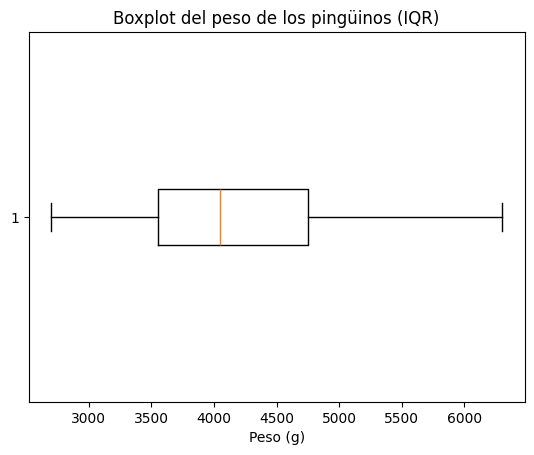

Peso mínimo: 2700.0 g
Peso máximo: 6300.0 g
Extremo inferior: 1750.0 g
Extremo superior: 6550.0 g
Número de outliers detectados: 0
Outliers:
[]


In [70]:
# Rango intercuartílico (IQR) con valor extremo
peso = data["body_mass_g"].dropna()
plt.boxplot(peso, vert=False)
plt.title("Boxplot del peso de los pingüinos (IQR)")
plt.xlabel("Peso (g)")
plt.show()
print(f"Peso mínimo: {peso.min()} g")
print(f"Peso máximo: {peso.max()} g")
Q1 = peso.quantile(0.25)
Q3 = peso.quantile(0.75)
IQR = Q3 - Q1
extremo_inferior = Q1 - 1.5 * IQR
extremo_superior = Q3 + 1.5 * IQR
print(f"Extremo inferior: {extremo_inferior} g")
print(f"Extremo superior: {extremo_superior} g")
outliers = peso[(peso < extremo_inferior) | (peso > extremo_superior)]
print(f"Número de outliers detectados: {len(outliers)}")
print("Outliers:")
print(outliers.values)

<Axes: >

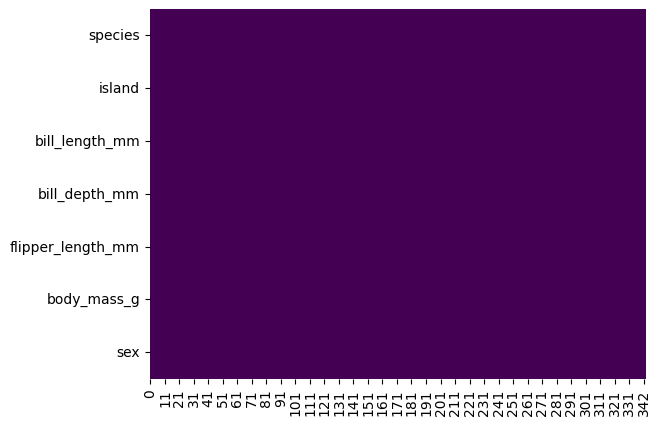

In [71]:
# validar valores nulos en el DataFrame segun un un mapa de calor
(
    data
    .isnull()
    .transpose()
    .pipe(
        lambda df: (
            sns.heatmap(
                df,
                cbar=False, # quitar barra de colores
                cmap='viridis', # escala de colores
                # yticklabels=True, # mostrar etiquetas en eje y

            )
        )
    )

)

In [72]:
####################DEMOSTRACIONES#####################

In [ ]:
#### Calcular la CDF usando la distribución normal #### (sin grafica)

# CUIDADO CUIDADO CUIDADO CUIDADO CUIDADO CUIDADO CUIDADO
## Caminos distintos para responder la misma pregunta. (hacen supuestos distintos sobre los datos)

# A. El camino de la Distribución Normal (norm.cdf)
# Usamos la distribución normal (paramétrica)
# Este camino modela los datos, no los usa tal cual.
# "mis pingüinos siguen una campana de Gauss perfecta"

# 1. Obtenemos la media y la desviación estándar de los pesos
media = data['body_mass_g'].mean()
desviacion = data['body_mass_g'].std()
# No se usa value_counts() como en PMF porque, los pesos no se repiten lo suficiente.
# 2. Calculamos P(peso <= 4000) usando la distribución normal
prob_acumulada = norm.cdf(4000, loc=media, scale=desviacion)
print(f"La probabilidad de que un pingüino pese 4000g o menos es: {prob_acumulada:.2%} (metodo paramétrico)")
# * Ajusta una normal teórica usando solo `media` y `desviación`
# * Calcula el área bajo la curva hasta 4000 g


# B. El camino empírico de la Media Lógica ((peso <= 4000).mean())
# Supuesto mínimo: Solo confío en los datos observados. (Este es el enfoque más directo y honesto)
# Este es el camino empírico (basado solo en los datos reales):
p_4000 = (peso <= 4000).mean()
# print(f"P(peso ≤ 4000 g) = {p_4000:.2f}")
print(f"La probabilidad de que un pingüino pese 4000g o menos es: {p_4000:.2%} (metodo empírico)")
# * Cuenta cuántos pingüinos pesan ≤ 4000 g
# * Divide entre el total

# NOTA: Comparación:
# una diferencia de 10% indica algo muy importante: Tus datos NO siguen una distribución normal.
# Hay asimetría: Tienes muchos pingüinos "ligeros" y un grupo de pingüinos muy "pesados" (probablemente los Gentoo). (VER 01_)

# C. El camino de la Distribución No Paramétrica (gaussian_kde)
# Usamos una distribución no paramétrica (gaussian_kde)
# "mis pingüinos no siguen una campana de Gauss perfecta"
# Los datos tienen una forma suave, pero no necesariamente normal.
# from scipy.stats import gaussian_kde
# 1. Creamos la distribución no paramétrica # Creamos el objeto KDE a partir de los datos reales (limpios de NaNs)
kde = gaussian_kde(data['body_mass_g'].dropna())
# 2. Calculamos la CDF evaluada en 4000g
prob_acumulada_kde = kde.integrate_box_1d(-np.inf, 4000)
print(f"La probabilidad de que un pingüino pese 4000g o menos es: {prob_acumulada_kde:.2%} (metodo no paramétrico)")
### ✔️ Qué hace realmente
# * Estima una PDF suave a partir de los datos reales
# * Integra esa densidad hasta 4000 g → CDF
# - Sensible al ancho de banda (bandwidth)


'''
La probabilidad de que un pingüino pese 4000g o menos es: 40.07% (metodo paramétrico)
La probabilidad de que un pingüino pese 4000g o menos es: 49.71% (metodo empírico)
La probabilidad de que un pingüino pese 4000g o menos es: 47.10% (metodo no paramétrico)}
CDF ≠ una sola fórmula, sino una idea: probabilidad acumulada
'''

print("CDF ≠ una sola fórmula, sino una idea: probabilidad acumulada")

# NOTAS: Aunque todos los métodos estiman la misma probabilidad acumulada, las diferencias entre ellos reflejan los distintos supuestos sobre la distribución subyacente de los datos. La discrepancia observada sugiere que el peso de los pingüinos no sigue una distribución normal

# NOTAS: Si quieres predecir cuánto pesará un pingüino en el futuro (en toda la Antártida): El modelo norm.cdf suele ser mejor porque intenta generalizar, pero solo si la población realmente sigue esa forma. Si quieres entender mejor a los pingüinos que ya tienes en tu dataset (por ejemplo, para hacer un análisis exploratorio): El modelo no paramétrico (gaussian_kde) suele ser mejor porque se adapta a la forma real de tus datos. El metodo empírico ((peso <= 4000).mean()) es el más simple y directo, pero puede ser menos preciso si tienes pocos datos o si los datos no representan bien a la población.










La probabilidad de que un pingüino pese 4000g o menos es: 40.07% (metodo paramétrico)
La probabilidad de que un pingüino pese 4000g o menos es: 49.71% (metodo empírico)
La probabilidad de que un pingüino pese 4000g o menos es: 47.10% (metodo no paramétrico)
CDF ≠ una sola fórmula, sino una idea: probabilidad acumulada


In [90]:
# Uso exploratorio de la mediana ####
# Mediana (percentil 50)
mediana = peso.quantile(0.5)
print(f"Mediana del peso: {mediana:.0f} g")
# 📌 En la CDF: El punto donde Y = 0.5

# Uso exploratorio del percentil 90 ####
# Caso 3: Percentil 90
p90 = peso.quantile(0.9)
print(f"Percentil 90 del peso: {p90:.0f} g")
# 📌 Interpretación: El 90% de los pingüinos pesa menos que este valor.




Mediana del peso: 4050 g
Percentil 90 del peso: 5400 g


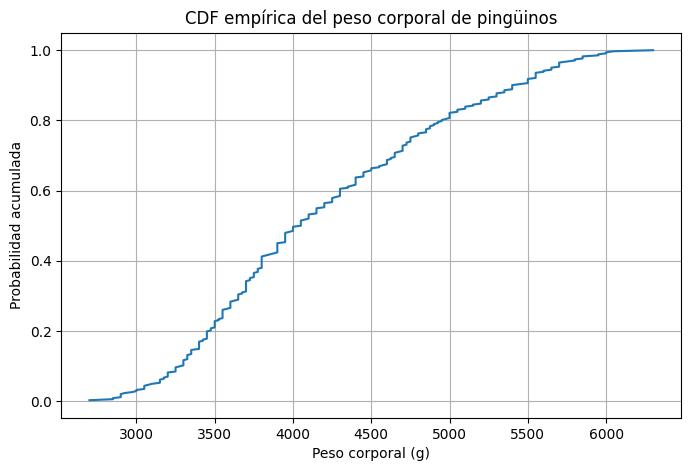

In [ ]:
#### Gráfica de la CDF empírica ####

peso = data['body_mass_g'].dropna()

# Ordenar valores
peso_sorted = peso.sort_values()

# CDF empírica
cdf = np.arange(1, len(peso_sorted) + 1) / len(peso_sorted)

plt.figure(figsize=(8, 5))
plt.plot(peso_sorted, cdf)
plt.xlabel("Peso corporal (g)")
plt.ylabel("Probabilidad acumulada")
plt.title("CDF empírica del peso corporal de pingüinos")
plt.grid(True)
plt.show()


In [75]:

# Opción 1: Discretizar (Agrupar en rangos o "bins")

# Esta es la forma de convertir una variable continua en algo parecido a una categoría.
# Es lo que hace un histograma internamente.Python

# Uso de bins
# Dividimos el peso en 5 rangos (bins) iguales
# peso_bins = pd.cut(data['body_mass_g'], bins=5)
# Ahora sí podemos usar value_counts(normalize=True)
# pmf_peso = peso_bins.value_counts(normalize=True).sort_index()
# display(pmf_peso)

# Uso de rangos personalizados
# Creamos cortes desde 2600 hasta 6400, saltando de 200 en 200
cortes = np.arange(2600, 6600, 200)
# Aplicamos los cortes
peso_bins_preciso = pd.cut(data['body_mass_g'], bins=cortes)
# Calculamos la probabilidad por rango
pmf_peso_200 = peso_bins_preciso.value_counts(normalize=True).sort_index()
print("PMF del peso corporal de pingüinos con cortes de 200g:")
print(pmf_peso_200)

print("-----"*5)
# Calcular CDF a partir de PMF
cdf_from_pmf = pmf_peso_200.cumsum()
print("CDF del peso corporal de pingüinos con cortes de 200g:")
display(cdf_from_pmf)




PMF del peso corporal de pingüinos con cortes de 200g:
body_mass_g
(2600, 2800]    0.002924
(2800, 3000]    0.029240
(3000, 3200]    0.049708
(3200, 3400]    0.087719
(3400, 3600]    0.114035
(3600, 3800]    0.128655
(3800, 4000]    0.084795
(4000, 4200]    0.067251
(4200, 4400]    0.073099
(4400, 4600]    0.049708
(4600, 4800]    0.076023
(4800, 5000]    0.058480
(5000, 5200]    0.035088
(5200, 5400]    0.043860
(5400, 5600]    0.040936
(5600, 5800]    0.032164
(5800, 6000]    0.020468
(6000, 6200]    0.002924
(6200, 6400]    0.002924
Name: proportion, dtype: float64
-------------------------
CDF del peso corporal de pingüinos con cortes de 200g:


body_mass_g
(2600, 2800]    0.002924
(2800, 3000]    0.032164
(3000, 3200]    0.081871
(3200, 3400]    0.169591
(3400, 3600]    0.283626
(3600, 3800]    0.412281
(3800, 4000]    0.497076
(4000, 4200]    0.564327
(4200, 4400]    0.637427
(4400, 4600]    0.687135
(4600, 4800]    0.763158
(4800, 5000]    0.821637
(5000, 5200]    0.856725
(5200, 5400]    0.900585
(5400, 5600]    0.941520
(5600, 5800]    0.973684
(5800, 6000]    0.994152
(6000, 6200]    0.997076
(6200, 6400]    1.000000
Name: proportion, dtype: float64

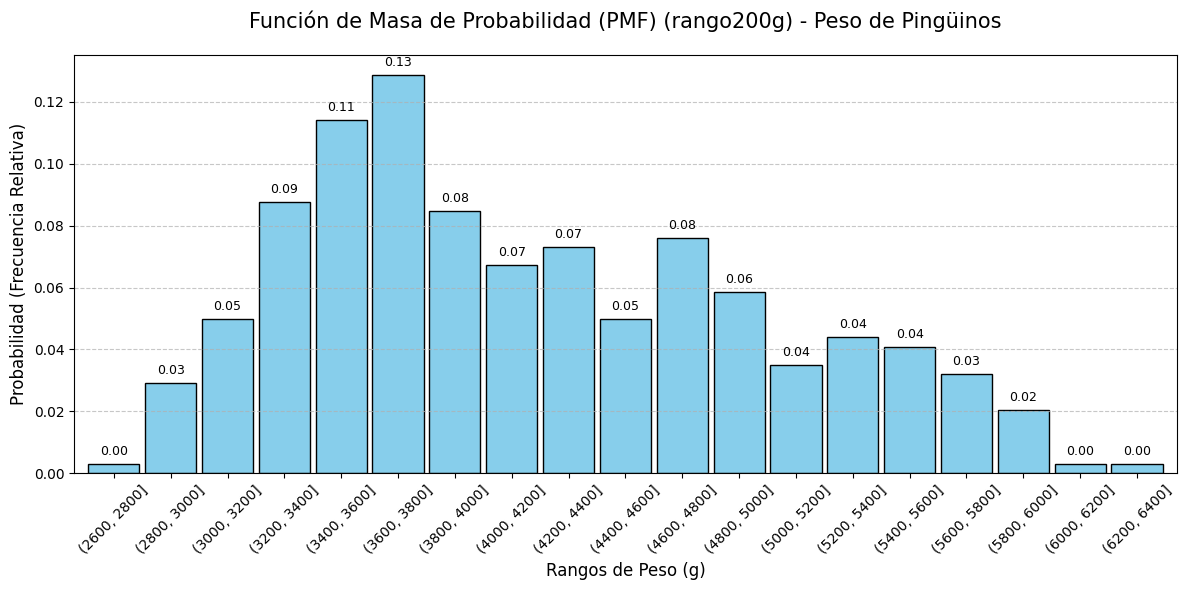

In [76]:
plt.figure(figsize=(12, 6))
# Usamos el índice de la serie (los rangos) como etiquetas en X
ax = pmf_peso_200.plot(kind='bar', color='skyblue', edgecolor='black', width=0.9)

plt.title('Función de Masa de Probabilidad (PMF) (rango200g) - Peso de Pingüinos', fontsize=15, pad=20)
plt.xlabel('Rangos de Peso (g)', fontsize=12)
plt.ylabel('Probabilidad (Frecuencia Relativa)', fontsize=12)
plt.xticks(rotation=45) # Rotamos las etiquetas para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadimos el valor sobre cada barra para mayor precisión
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

Gráfica de Escalones o una línea con área rellena


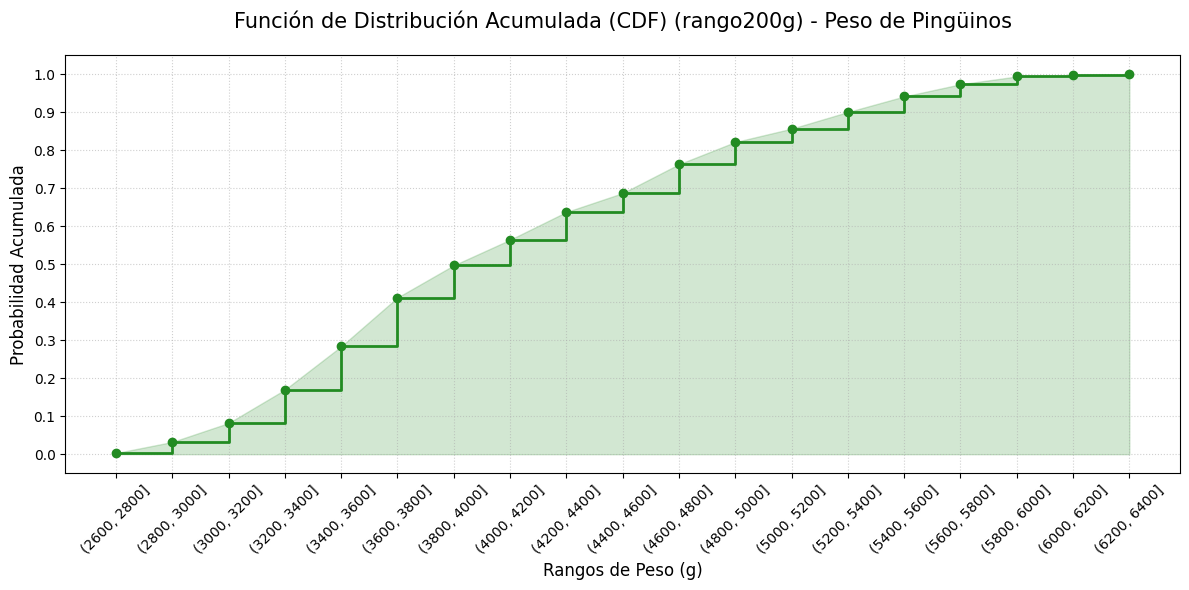

In [77]:
plt.figure(figsize=(12, 6))

# Graficamos la CDF como una línea con puntos (marcadores)
cdf_from_pmf.plot(drawstyle='steps-post', marker='o', color='forestgreen', linewidth=2)

plt.fill_between(range(len(cdf_from_pmf)), cdf_from_pmf, color='forestgreen', alpha=0.2)

plt.title('Función de Distribución Acumulada (CDF) (rango200g) - Peso de Pingüinos', fontsize=15, pad=20)
plt.xlabel('Rangos de Peso (g)', fontsize=12)
plt.ylabel('Probabilidad Acumulada', fontsize=12)
plt.xticks(range(len(cdf_from_pmf)), cdf_from_pmf.index, rotation=45)
plt.yticks(np.arange(0, 1.1, 0.1)) # Marcamos del 0 al 1 de diez en diez
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
print("Gráfica de Escalones o una línea con área rellena")
plt.show()
# Generalmente, donde la línea sube más "verticalmente", es donde hay más pingüinos concentrados. (ver el cambio en las alturas de las barras)

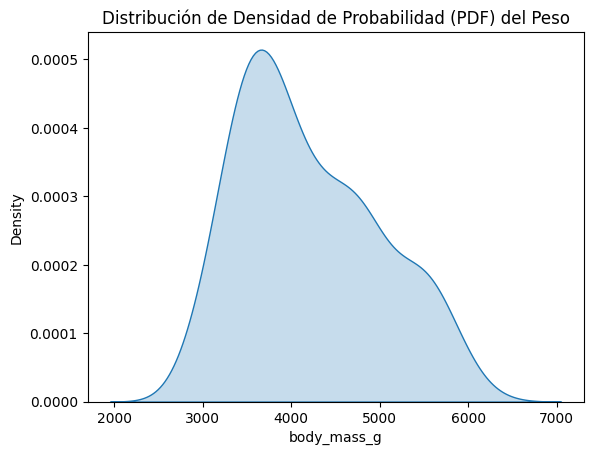

En una PDF, el valor del eje Y NO es la probabilidad. Se llama Densidad.
En una PDF, el área bajo la curva entre dos puntos representa la probabilidad de que la variable caiga dentro de ese rango.
En una PDF, el área total bajo la curva es igual a 1 (o 100%).
La PDF se usa para entender la distribución y la dispersión sin el "ruido" de las cajas (bins).
Para obtener la CDF a partir de la PDF, se integra el área bajo la curva desde el valor mínimo hasta un valor específico.


In [78]:
# Opción 2: Usar una Estimación de Densidad de Kernel (KDE) // Aplicacion de PDF
# Si quieres la "probabilidad" real de una variable continua sin agruparla en cajas, necesitas la PDF. En código, esto se hace con Seaborn:
# Python:
# import seaborn as sns
# import matplotlib.pyplot as plt
# Esto genera la curva de densidad (PDF)
sns.kdeplot(data=data, x='body_mass_g', fill=True)
plt.title("Distribución de Densidad de Probabilidad (PDF) del Peso")
plt.show()
print("En una PDF, el valor del eje Y NO es la probabilidad. Se llama Densidad.")
print("En una PDF, el área bajo la curva entre dos puntos representa la probabilidad de que la variable caiga dentro de ese rango.")
print("En una PDF, el área total bajo la curva es igual a 1 (o 100%).")
print("La PDF se usa para entender la distribución y la dispersión sin el \"ruido\" de las cajas (bins).")
print("Para obtener la CDF a partir de la PDF, se integra el área bajo la curva desde el valor mínimo hasta un valor específico.")

Y aunque la CDF se define desde $-\infty$ hasta un punto $X$, puedes encontrar la probabilidad de un rango $[A, B]$ simplemente restando dos valores de la CDF.  

La lógica es esta:  
$P(X \le 4000)$: Todo lo que pesa 4000 g o menos.  
$P(X \le 3000)$: Todo lo que pesa 3000 g o menos.  
Rango ($3000$ a $4000$): Si a "todo lo menor a 4000" le quitas "todo lo menor a 3000", te queda exactamente el área entre 3000 y 4000.  
  
$$P(3000 \le X \le 4000) = CDF(4000) - CDF(3000)$$

In [ ]:
# from scipy.stats import gaussian_kde

# 1. Creamos el objeto KDE a partir de los datos reales (limpios de NaNs)
pesos = data['body_mass_g'].dropna()
kde = gaussian_kde(pesos)

# 2. Calculamos la probabilidad integrando el área bajo la curva entre 2000 y 3000
# El método .integrate_box_1d hace el trabajo de restar las CDFs por ti
prob_rango = kde.integrate_box_1d(3000, 4000)

print(f"Probabilidad de pesar entre 3000g y 4000g: {prob_rango:.2%}")

Probabilidad de pesar entre 3000g y 4000g: 42.41%


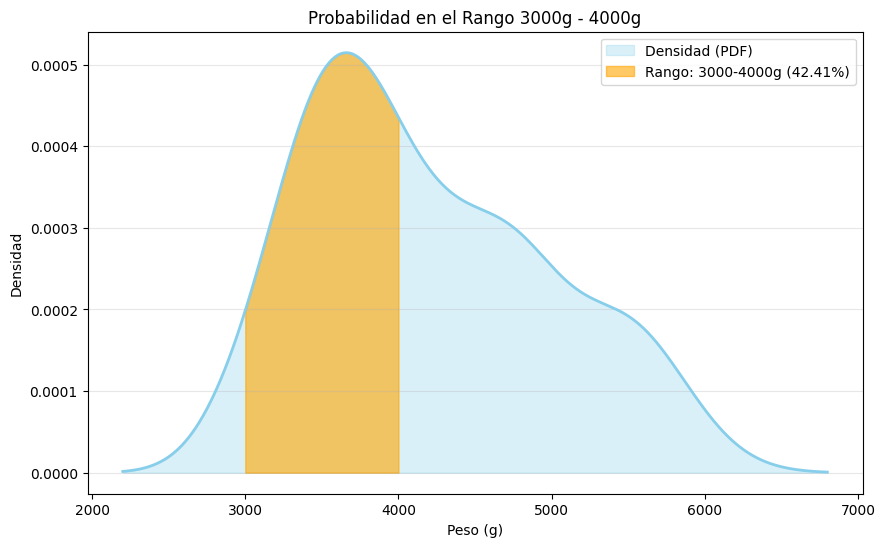

La probabilidad calculada es: 42.41%


In [80]:

#### INTENTO UNO (2) pero da error "list index out of range" de todas formas - se deja para documentacion- ####
# # 1. Preparación de datos (Limpieza obligatoria)
# pesos = data['body_mass_g'].dropna()
# # 2. Cálculo matemático de la probabilidad con KDE
# kde = gaussian_kde(pesos)
# prob_rango = kde.integrate_box_1d(3000, 4000)
# # 3. Graficación
# plt.figure(figsize=(10, 6))
# ax = sns.kdeplot(data=data, x='body_mass_g', fill=True, color="skyblue", label="Densidad (PDF)")
# # Extraer datos directamente del objeto 'ax' para evitar el error de índice (ERROR list index out of range)
# x_plot = ax.lines[0].get_xdata()
# y_plot = ax.lines[0].get_ydata()
# # 4. Sombreado del rango 3000 - 4000
# plt.fill_between(x_plot, y_plot, where=(x_plot >= 3000) & (x_plot <= 4000), 
#                  color='orange', alpha=0.5, label=f'Rango: 3000-4000g ({prob_rango:.2%})')
# plt.title("Probabilidad en el Rango Específico (Área bajo la PDF)")
# plt.xlabel("Peso (g)")
# plt.ylabel("Densidad")
# plt.legend()
# plt.show()
# print(f"La probabilidad de encontrar un pingüino entre 3000g y 4000g es: {prob_rango:.2%}")



# 1. Preparación y cálculo
pesos = data['body_mass_g'].dropna()
kde = gaussian_kde(pesos)
prob_rango = kde.integrate_box_1d(3000, 4000)

# 2. Crear un rango de X para la curva suave
x_curva = np.linspace(pesos.min() - 500, pesos.max() + 500, 500)
y_curva = kde(x_curva)

# 3. Graficación
plt.figure(figsize=(10, 6))

# Dibujamos la línea y el relleno general manualmente para tener control total
plt.plot(x_curva, y_curva, color='skyblue', lw=2)
plt.fill_between(x_curva, y_curva, color='skyblue', alpha=0.3, label="Densidad (PDF)")

# 4. Sombreado del rango específico (3000 - 4000)
x_rango = np.linspace(3000, 4000, 100)
y_rango = kde(x_rango)
plt.fill_between(x_rango, y_rango, color='orange', alpha=0.6, 
                 label=f'Rango: 3000-4000g ({prob_rango:.2%})')

plt.title("Probabilidad en el Rango 3000g - 4000g")
plt.xlabel("Peso (g)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"La probabilidad calculada es: {prob_rango:.2%}")

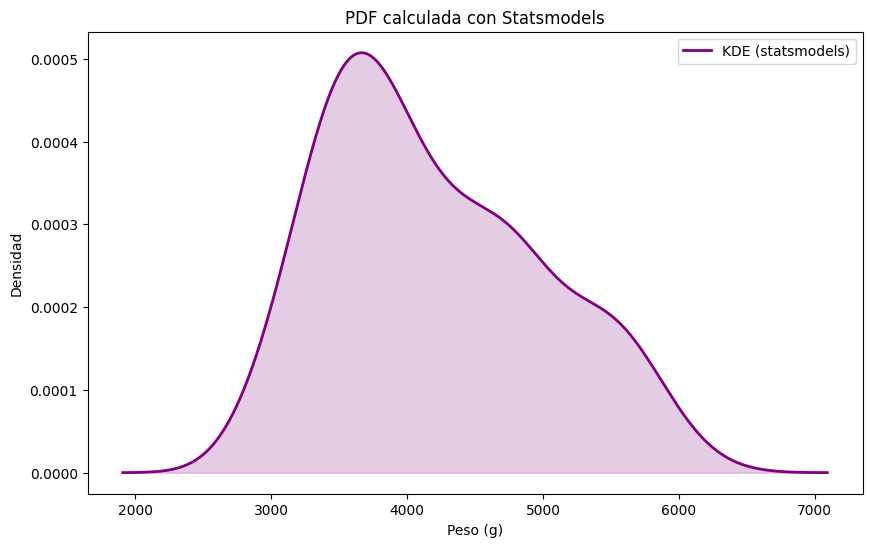

In [ ]:
#### SOLO DEMOSTRATIVO ###################################################################
import statsmodels.api as sm  # ("Distribución No Paramétrica Avanzada"): Se usa cuando necesitas realizar pruebas estadísticas rigurosas o modelos econométricos.

# statsmodels	--	Cuando necesitas realizar pruebas estadísticas rigurosas o modelos econométricos.
# Crea una distribución empírica mucho más robusta
# Puedes obtener la CDF, PDF y más de forma muy profesional

# 1. Cálculo
kde_sm = sm.nonparametric.KDEUnivariate(data['body_mass_g'].dropna())
kde_sm.fit() # Aquí se calculan los números, pero no se dibuja

# 2. Graficación manual
plt.figure(figsize=(10, 6))
plt.plot(kde_sm.support, kde_sm.density, color='purple', lw=2, label='KDE (statsmodels)')
plt.fill_between(kde_sm.support, kde_sm.density, color='purple', alpha=0.2)

plt.title("PDF calculada con Statsmodels")
plt.xlabel("Peso (g)")
plt.ylabel("Densidad")
plt.legend()
plt.show()


